# This is for Ellitpic, not Elliptic++

In [143]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go 
import plotly.offline as py 
import math
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'

## Fetch Dataset

This is elliptic++ dataset, and we will later transform it to elliptic which remove the last 17 features in txs_features.csv

In [ ]:
import gdown
!gdown --fuzzy "https://drive.google.com/file/d/19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1DiBxn8TXdbJqoSw58pYUeaqO3oOKhuQO/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1Q2yG_CIDvfdGP-fKVPSw979EYgQukjz5/view?usp=drive_link"

Downloading...
From (original): https://drive.google.com/uc?id=19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc
From (redirected): https://drive.google.com/uc?id=19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc&confirm=t&uuid=5853c9a0-e793-4b23-993c-797b3cd39601
To: /Users/fffuuuming/Desktop/study/master_1_2/fintech/final_project/impl/elliptic-fork/elliptic/txs_features.csv
  2%|▉                                      | 17.3M/695M [00:03<02:14, 5.03MB/s]^C
  File "/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/urllib3/response.py", line 862, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
  File "/opt/anaconda3/envs/elliptic-fork/lib/python3.10/http/client.py", line 466, in read
    s = self.fp.read(amt)
  File "/opt/anaconda3/envs/elliptic-fork/lib/python3.10/socket.py", line 717, in readinto
    return self._sock.recv_into(b)
  File "/opt/anaconda3/envs/elliptic-fork/lib/python3.10/ssl.py", line 1307, in recv_into
    return self.read(nbytes, buffer)
  File "/opt/a

## Data Preprocessing

1. Fetch dataset
2. Drop augmented features (Elliptic++)

In [144]:
df_txs_features = pd.read_csv("txs_features.csv")
# Remove the last 17 columns which are only for 
df_txs_features = df_txs_features.iloc[:, :-17]

df_txs_classes = pd.read_csv("txs_classes.csv")
df_txs_edgelist = pd.read_csv("txs_edgelist.csv")

In [33]:
df_txs_features.keys()

Index(['txId', 'Time step', 'Local_feature_1', 'Local_feature_2',
       'Local_feature_3', 'Local_feature_4', 'Local_feature_5',
       'Local_feature_6', 'Local_feature_7', 'Local_feature_8',
       ...
       'Aggregate_feature_63', 'Aggregate_feature_64', 'Aggregate_feature_65',
       'Aggregate_feature_66', 'Aggregate_feature_67', 'Aggregate_feature_68',
       'Aggregate_feature_69', 'Aggregate_feature_70', 'Aggregate_feature_71',
       'Aggregate_feature_72'],
      dtype='object', length=167)

3. Merge label into txs_features for later index mapping

In [145]:
subset = df_txs_classes[['txId', 'class']]

# 2. 用 merge 把 class 欄併到 txs_features
df_txs_features_merged = df_txs_features.merge(
    subset,
    on='txId',     # 以 txId 當作 key
    how='left'     # 保留 txs_features 所有列，對不到的 class 欄會是 NaN
)

In [132]:
df_txs_features_merged

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,-0.500080,0.241128,0.241406,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,-0.600999,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,-0.607306,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,0.982479,0.118347,0.091066,-0.098889,0.854508,-0.066727,-0.150067,-0.080760,-0.070977,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,-0.556847,1.461330,1.461369,0.018279,0.181652,0.519580,0.505505,1.519700,1.521399,3
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,-0.424391,-0.979074,-0.978556,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,3
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,-0.506387,1.461330,1.461369,0.018279,0.143203,0.426618,0.419358,1.519700,1.521399,3


4. Normalize features (commented)

In [ ]:
# # For notmalize augmented features
# from sklearn.preprocessing import MinMaxScaler

# for column in df_txs_features_merged.columns[:-1]:
#     scaler = MinMaxScaler()
#     df_txs_features_merged[column] = scaler.fit_transform(df_txs_features_merged[[column]])

In [64]:
df_txs_features_merged

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,-0.500080,0.241128,0.241406,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,-0.600999,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,-0.607306,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,0.982479,0.118347,0.091066,-0.098889,0.854508,-0.066727,-0.150067,-0.080760,-0.070977,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,158304003,49,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,...,-0.556847,1.461330,1.461369,0.018279,0.181652,0.519580,0.505505,1.519700,1.521399,3
203765,158303998,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,3
203766,158303966,49,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,...,-0.424391,-0.979074,-0.978556,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,3
203767,161526077,49,-0.172212,-0.139573,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.162856,...,-0.506387,1.461330,1.461369,0.018279,0.143203,0.426618,0.419358,1.519700,1.521399,3


5. Set `txId` as the index for the processed DataFrame
6. Updates the index of the Dataframe with ```id_map```
7. Constructs `edge_index`

In [146]:
import torch

df_txs_features_processed = df_txs_features_merged.set_index('txId')

ids_from_src      = df_txs_edgelist['txId1']
ids_from_dst      = df_txs_edgelist['txId2']
all_ids = pd.unique(pd.concat([ids_from_src, ids_from_dst]))
id_map  = {orig_id: idx for idx, orig_id in enumerate(all_ids)}

df_txs_features_processed.index = df_txs_features_processed.index.map(id_map)

src = df_txs_edgelist['txId1'].map(id_map).values
dst = df_txs_edgelist['txId2'].map(id_map).values
edge_index = torch.tensor(np.stack([src, dst]), dtype=torch.long)

8. Extract labels and transform `licit` & `unknown`
9. Extract time steps and create mask

In [147]:
y = df_txs_features_processed['class'].copy()
y[y == 2] = 0   # licit
y[y == 3] = 2   # unknown


time_steps = df_txs_features_processed['Time step']

train_mask, test_mask = time_steps <= 34, time_steps > 34
train_mask = torch.tensor(train_mask.to_numpy(), dtype=torch.bool)
test_mask = torch.tensor(test_mask.to_numpy(), dtype=torch.bool)

time_steps = torch.tensor(time_steps.to_numpy(), dtype=torch.int64)

In [148]:
y

txId
166567    2
2337      2
6025      2
6526      0
67        0
         ..
165408    2
203532    2
203542    2
165036    2
165296    2
Name: class, Length: 203769, dtype: int64

10. Drop label & time step

In [149]:
df_txs_features_final = df_txs_features_processed.drop(columns=['class', 'Time step'])
df_txs_features_final

,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,Local_feature_10,...,Aggregate_feature_63,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72
txId,,,,,,,,,,,,,,,,,,,,,
166567,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,-0.166062,-0.049707,...,-0.577099,-0.500080,0.241128,0.241406,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399
2337,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,-0.133751,-0.049707,...,-0.562153,-0.600999,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
6025,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,-0.166555,-0.049707,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
6526,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,-0.118555,0.300047,...,-0.569626,-0.607306,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
67,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,5.252974,-0.049707,...,1.258630,0.982479,0.118347,0.091066,-0.098889,0.854508,-0.066727,-0.150067,-0.080760,-0.070977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165408,-0.165622,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156113,-0.162033,-0.049707,...,-0.509843,-0.556847,1.461330,1.461369,0.018279,0.181652,0.519580,0.505505,1.519700,1.521399
203532,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,-0.163463,-0.049707,...,-0.554681,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
203542,-0.167040,-0.139563,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.157564,-0.163463,-0.049707,...,-0.412695,-0.424391,-0.979074,-0.978556,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984


11. Create raw graph (PyTorch Geometric Data)

In [150]:
from torch_geometric.data import Data

x = torch.tensor(df_txs_features_final.values, dtype=torch.float)
data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask, node_time=time_steps)
data.y = torch.from_numpy(data.y.to_numpy().astype(int)).long()

## (i) Naive random splitting on entire graph + joint learning

This approach simply sample negative edge from all edges without considering time step, and it jointly train GAE encoder and classifier without weighted loss or balance data

In [353]:
from torch_geometric.transforms import RandomLinkSplit

splitter = RandomLinkSplit(
    is_undirected=False,
    split_labels=True,          
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0,
    num_val=0,
    num_test=0,
)
train_data, _, _ = splitter(data)

In [354]:
print(data.keys())
print(train_data.keys())

for key in ['x', 'y', 'train_mask', 'test_mask', 'node_time', 'edge_index']:
    print(key, torch.equal(getattr(data, key), getattr(train_data, key)))

['x', 'train_mask', 'node_time', 'test_mask', 'edge_index', 'y']
['x', 'pos_edge_label', 'neg_edge_label_index', 'train_mask', 'node_time', 'pos_edge_label_index', 'neg_edge_label', 'test_mask', 'edge_index', 'y']
x True
y True
train_mask True
test_mask True
node_time True
edge_index False


In [100]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import f1_score, precision_score, recall_score

# 2) Encoder + Classifier
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class NodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.lin = torch.nn.Linear(in_channels, num_classes)
    def forward(self, z):
        return self.lin(z)

in_feats    = data.num_node_features
hidden_dim  = 128
out_dim     = 64
num_classes = int(data.y[data.y != 2].max() + 1)

encoder    = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model  = GAE(encoder)
classifier = NodeClassifier(out_dim, num_classes)

optimizer = torch.optim.Adam(
    list(gae_model.parameters()) + list(classifier.parameters()),
    lr=0.01
)
bce_loss = torch.nn.BCEWithLogitsLoss()
ce_loss  = torch.nn.CrossEntropyLoss()

# 3) train() 改用 train_pos/neg
def train():
    gae_model.train()
    classifier.train()
    optimizer.zero_grad()

    # encode on train positive edges
    z = gae_model.encode(train_data.x, train_data.edge_index)

    # AE loss (pos + neg)
    pos = train_data.pos_edge_label_index
    neg = train_data.neg_edge_label_index
    edge_all = torch.cat([pos, neg], dim=1)
    logits_ae = gae_model.decode(z, edge_all)
    labels_ae = torch.cat([
        torch.ones(pos.size(1), device=logits_ae.device),
        torch.zeros(neg.size(1), device=logits_ae.device),
    ])
    loss_ae = bce_loss(logits_ae, labels_ae)

    # classification loss (only known & train_mask)
    mask = data.train_mask.detach().clone() & (data.y != 2)

    logits_cls = classifier(z)
    loss_cls = ce_loss(logits_cls[mask], train_data.y[mask])

    loss = loss_ae + loss_cls
    loss.backward()
    optimizer.step()

    return loss.item(), loss_ae.item(), loss_cls.item()

# 4) evaluate() 只用 train_data.train_pos_edge_index encode
def evaluate():
   
    with torch.no_grad():
        z = gae_model.encode(train_data.x, train_data.edge_index) 
        logits = classifier(z)
        preds  = logits.argmax(dim=1)
   
        mask = data.test_mask.detach().clone() & (data.y != 2)
  
        y_true = data.y[mask].cpu().numpy()
        y_pred = preds[mask].cpu().numpy()

        acc  = (y_true == y_pred).mean().item()
        prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
        rec  = recall_score(y_true, y_pred, average='macro')
        f1   = f1_score(y_true, y_pred, average='macro')
        print(f"Test Acc={acc:.4f} | "
              f"Precision={prec:.4f} | "
              f"Recall={rec:.4f} | "
              f"F1={f1:.4f}")
        return acc

for epoch in range(1, 101):
    loss_tot, loss_ae, loss_cls = train()
    print(f"Epoch {epoch:03d} | "
              f"Loss={loss_tot:.4f} (AE={loss_ae:.4f}, CLF={loss_cls:.4f})")
    if epoch % 10 == 0:
        test_acc= evaluate()

NameError: name 'train_data' is not defined

## (ii) Single Graph Dataset

This Dataset contains only single graph, but it samples negative edges based on time step, 
e.g. sample (u, v) only if 
1. (u, v) is not an edge
2. u.time_step = v .time_step

In [288]:
import random

def sample_same_timestep_negative_edges(data: Data, neg_per_pos=1):
    node_time = data.node_time
    edge_index = data.edge_index
    num_nodes = data.num_nodes

    # Step 1: Build positive edge list
    pos_edge_index = edge_index

    # Step 2: Group node indices by time
    time_to_nodes = {}
    for t in torch.unique(node_time):
        nodes = (node_time == t).nonzero(as_tuple=True)[0].tolist()
        time_to_nodes[t.item()] = nodes

    # Step 3: Build a set of existing edges for quick lookup
    existing_edges = set((u.item(), v.item()) for u, v in edge_index.t())

    # Step 4: Sample negative edges within each timestep
    neg_edges = []
    max_trials = 10 * len(nodes) ** 2  # safeguard to avoid infinite loop     

    for t, nodes in time_to_nodes.items():
        trials = 0
        sampled = 0
        while sampled < neg_per_pos * len(pos_edge_index[0]) and trials < max_trials:
            u, v = random.sample(nodes, 2)
            if (u, v) not in existing_edges and (v, u) not in existing_edges and u != v:
                neg_edges.append((u, v))
                sampled += 1
            trials += 1

    # Step 5: Convert to tensors
    neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t()
    pos_edge_label = torch.ones(pos_edge_index.size(1), dtype=torch.float)
    neg_edge_label = torch.zeros(neg_edge_index.size(1), dtype=torch.float)

    edge_label_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    edge_label = torch.cat([pos_edge_label, neg_edge_label], dim=0)

    return edge_label_index, edge_label

In [289]:
edge_label_index, edge_label = sample_same_timestep_negative_edges(data, neg_per_pos=1)

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import f1_score, precision_score, recall_score


# 2) Encoder + Classifier
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)
    
in_feats    = data.num_node_features
hidden_dim  = 128
out_dim     = 64
num_classes = int(data.y[data.y != 2].max() + 1)

encoder    = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model  = GAE(encoder)

optimizer = torch.optim.Adam(
    list(gae_model.parameters()),
    lr=0.001
)
bce_loss = torch.nn.BCEWithLogitsLoss()



epochs = 100
for epoch in range(1, epochs+1):
    _ = gae_model.train()
    optimizer.zero_grad()

    z = gae_model.encode(data.x, data.edge_index)  # Full graph for encoder
    logits = gae_model.decode(z, edge_label_index).view(-1)
    loss = F.binary_cross_entropy_with_logits(logits, edge_label)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

Epoch 001 | Loss: 1.2728
Epoch 002 | Loss: 1.2507
Epoch 003 | Loss: 1.2195
Epoch 004 | Loss: 1.1822
Epoch 005 | Loss: 1.1425
Epoch 006 | Loss: 1.1043
Epoch 007 | Loss: 1.0706
Epoch 008 | Loss: 1.0430
Epoch 009 | Loss: 1.0221
Epoch 010 | Loss: 1.0074
Epoch 011 | Loss: 0.9979
Epoch 012 | Loss: 0.9926
Epoch 013 | Loss: 0.9902
Epoch 014 | Loss: 0.9895
Epoch 015 | Loss: 0.9898
Epoch 016 | Loss: 0.9904
Epoch 017 | Loss: 0.9908
Epoch 018 | Loss: 0.9908
Epoch 019 | Loss: 0.9902
Epoch 020 | Loss: 0.9891
Epoch 021 | Loss: 0.9876
Epoch 022 | Loss: 0.9858
Epoch 023 | Loss: 0.9837
Epoch 024 | Loss: 0.9815
Epoch 025 | Loss: 0.9793
Epoch 026 | Loss: 0.9771
Epoch 027 | Loss: 0.9750
Epoch 028 | Loss: 0.9730
Epoch 029 | Loss: 0.9711
Epoch 030 | Loss: 0.9694
Epoch 031 | Loss: 0.9678
Epoch 032 | Loss: 0.9665
Epoch 033 | Loss: 0.9652
Epoch 034 | Loss: 0.9642
Epoch 035 | Loss: 0.9632
Epoch 036 | Loss: 0.9623
Epoch 037 | Loss: 0.9615
Epoch 038 | Loss: 0.9607
Epoch 039 | Loss: 0.9600
Epoch 040 | Loss: 0.9593


KeyboardInterrupt: 

## (iii) Temporal Graph Dataset
This dataset contain all sub-graphs from 1 ~ 49, with each sampled negative edges separately, note that currently sub-graph start from 42 is `None` due to no edge issue

In [151]:
import torch
import random
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.transforms import RandomLinkSplit

class PerTimestepEdgeLabelDataset(InMemoryDataset):
    def __init__(self, data: Data, neg_sampling_ratio=1.0):
        super().__init__("/tmp")
        self.data_list = []

        for t in torch.unique(data.node_time):

            # # sub-graph from time step 42 has no edges
            # if t >= 42:
            #     break
            
            print(f"t = {t}")
            subgraph_t = self.build_subgraph(data, t)
            # print(f"sub-graph{t}: {subgraph_t}")
            train_data_t = self.random_split(subgraph_t, neg_sampling_ratio=neg_sampling_ratio)
            
            self.data_list.append(train_data_t)

    def build_subgraph(self, data, time_step):

        node_mask = data.node_time == time_step
        # no nodes at this time step
        if node_mask.sum() == 0:
            return None

        src, dst = data.edge_index
        edge_mask = node_mask[src] & node_mask[dst]
        edge_index_t = data.edge_index[:, edge_mask]
        node_indices = node_mask.nonzero(as_tuple=True)[0]

        # keep x, y whose time step = time_step
        x_t, y_t = data.x[node_indices], data.y[node_indices]
        node_time_t = data.node_time[node_indices]

        # 建圖時重新編號節點 (Optional: for cleaner subgraph)
        index_map = torch.full((data.num_nodes,), -1, dtype=torch.long)
        index_map[node_indices] = torch.arange(node_indices.size(0))
        edge_index_t = index_map[edge_index_t]

        return Data(
            x=x_t,
            y=y_t,
            edge_index=edge_index_t,    
            num_nodes=node_indices.size(0),
            node_time=node_time_t,
        )
        

    def random_split(self, data, neg_sampling_ratio=1.0):
        splitter = RandomLinkSplit(
            is_undirected=False,
            split_labels=False,
            add_negative_train_samples=True,
            neg_sampling_ratio=neg_sampling_ratio,
            num_val=0,
            num_test=0,
        )
        try:
            train_data_t, _, _ = splitter(data)
            # print(train_data_t)
            assert isinstance(train_data_t, Data)
            return train_data_t
        except Exception as e:
            print(f"Skipping timestep {data.node_time[0]} due to error: {e}")
            return None


    def hard_negative_split(self, data, neg_sampling_ratio=1, k_hop_neighbors=1):
        from torch_geometric.utils import k_hop_subgraph

        edge_index = data.edge_index
        node_time = data.node_time
        pos_edge_index = edge_index
        existing_edges = set((u.item(), v.item()) for u, v in edge_index.t())

        neg_edges = []
        for u in range(data.num_nodes):
            if len(neg_edges) >= neg_sampling_ratio * edge_index.size(1):
                break
            # Get k-hop neighbors of u
            subset, _, _, _ = k_hop_subgraph(u, num_hops=k_hop_neighbors, edge_index=edge_index, relabel_nodes=False)
            neighbors = set(subset.tolist())
            candidates = set(range(data.num_nodes)) - neighbors - {u}
            if len(candidates) == 0:
                continue
            v = random.choice(list(candidates))
            if (u, v) not in existing_edges and (v, u) not in existing_edges:
                neg_edges.append((u, v))

        if len(neg_edges) == 0:
            return None  # skip empty

        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t()
        pos_edge_label = torch.ones(pos_edge_index.size(1), dtype=torch.float)
        neg_edge_label = torch.zeros(neg_edge_index.size(1), dtype=torch.float)

        edge_label_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
        edge_label = torch.cat([pos_edge_label, neg_edge_label], dim=0)

        return Data(
            x=data.x,
            edge_index=data.edge_index,
            edge_label_index=edge_label_index,
            edge_label=edge_label,
            node_time=data.node_time,
        )


    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

In [152]:
from torch_geometric.loader import DataLoader

dataset = PerTimestepEdgeLabelDataset(data, neg_sampling_ratio=1.0)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

t = 1
t = 2
t = 3
t = 4
t = 5
t = 6
t = 7
t = 8
t = 9
t = 10
t = 11
t = 12
t = 13
t = 14
t = 15
t = 16
t = 17
t = 18
t = 19
t = 20
t = 21
t = 22
t = 23
t = 24
t = 25
t = 26
t = 27
t = 28
t = 29
t = 30
t = 31
t = 32
t = 33
t = 34
t = 35
t = 36
t = 37
t = 38
t = 39
t = 40
t = 41
t = 42
t = 43
Skipping timestep 43 due to error: Insufficient number of edges for training
t = 44
Skipping timestep 44 due to error: Insufficient number of edges for training
t = 45
Skipping timestep 45 due to error: Insufficient number of edges for training
t = 46
Skipping timestep 46 due to error: Insufficient number of edges for training
t = 47
Skipping timestep 47 due to error: Insufficient number of edges for training
t = 48
Skipping timestep 48 due to error: Insufficient number of edges for training
t = 49
Skipping timestep 49 due to error: Insufficient number of edges for training


In [79]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_tsne_binary(model, data, stage='before'):
    model.eval()
    with torch.no_grad():
        z = model(data.x, data.edge_index)

    # 🟢 Filter nodes with class 0 or 1
    mask = (data.y == 0) | (data.y == 1)
    if mask.sum() == 0:
        raise ValueError("No nodes with label 0 or 1 found.")
        
    z_filtered = z[mask]
    y_filtered = data.y[mask]

    # 🔵 Convert to CPU numpy arrays
    z_np = z_filtered.detach().cpu().numpy()
    y_np = y_filtered.detach().cpu().numpy()

    # 🟥 Map y=0 → green, y=1 → red
    color_map = np.where(y_np == 0, 'green', 'red')

    # 🔵 t-SNE projection
    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(z_np)

    # 🔴 Plot
    plt.figure(figsize=(8, 6))
    for label, color in zip([0, 1], ['green', 'red']):
        idx = y_np == label
        plt.scatter(z_2d[idx, 0], z_2d[idx, 1], c=color, label=f"Class {label}", s=10)

    plt.legend()
    plt.title(f"t-SNE of Embeddings for Class 0 (green) and 1 (red) ({stage} training)")
    plt.show()

In [89]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Define Encoder
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)
    

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_term = self.alpha * (1 - pt) ** self.gamma
        loss = focal_term * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

### Test on subgraph 1 (tiem step = 1)

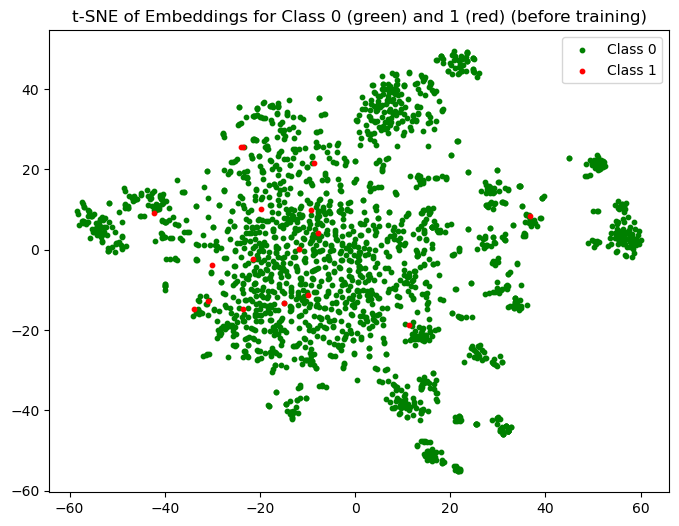

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no 

Epoch 001 | Loss: 0.8132 | AUC: 0.6219 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 002 | Loss: 0.8132 | AUC: 0.6319 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 003 | Loss: 0.8132 | AUC: 0.6409 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 004 | Loss: 0.8132 | AUC: 0.6494 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 005 | Loss: 0.8131 | AUC: 0.6577 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 006 | Loss: 0.8130 | AUC: 0.6664 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 007 | Loss: 0.8129 | AUC: 0.6744 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 008 | Loss: 0.8128 | AUC: 0.6819 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 009 | Loss: 0.8125 | AUC: 0.6904 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000


/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/opt/anaconda3/envs/elliptic-fork/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no 

Epoch 010 | Loss: 0.8122 | AUC: 0.6981 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 011 | Loss: 0.8119 | AUC: 0.7054 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 012 | Loss: 0.8114 | AUC: 0.7136 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 013 | Loss: 0.8107 | AUC: 0.7208 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 014 | Loss: 0.8100 | AUC: 0.7275 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 015 | Loss: 0.8090 | AUC: 0.7329 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 016 | Loss: 0.8078 | AUC: 0.7384 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 017 | Loss: 0.8063 | AUC: 0.7446 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 018 | Loss: 0.8046 | AUC: 0.7503 | F1: 0.6667 | Precision: 0.5001 | Recall: 1.0000
Epoch 019 | Loss: 0.8025 | AUC: 0.7570 | F1: 0.6667 | Precision: 0.5001 | Recall: 1.0000
Epoch 020 | Loss: 0.8000 | AUC: 0.7631 | F1: 0.6667 | Precision: 0.5001 | Recall: 1.0000
Epoch 021 | Loss: 0.7

In [140]:
from sklearn.metrics import precision_recall_fscore_support

# Model & Optimizer
in_feats = data.num_node_features
hidden_dim = 256
out_dim = 128
encoder = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.0001)
bce_loss = torch.nn.BCEWithLogitsLoss()
# focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# Get training subgraph (time step 1)
train_batch = dataset[0]

visualize_tsne_binary(gae_model, train_batch, stage='before')

def train_single_graph(train_batch):

    loss_list, auc_list, f1_list, precision_list, recall_list = [], [], [], [], []
    epochs = 300

    for epoch in range(1, epochs + 1):
        _ = gae_model.train()
        optimizer.zero_grad()

        # Forward
        z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
        edge_label_index = train_batch.edge_label_index.squeeze(0)
        edge_label = train_batch.edge_label.squeeze(0).float()
        logits = gae_model.decode(z, edge_label_index).view(-1)

        # Loss
        loss = bce_loss(logits, edge_label)
        # loss = focal_loss(logits, edge_label)
        loss.backward()
        optimizer.step()

        # Evaluation
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu()
            # print(f"probs: {probs}")
            # print(f"edge_label_index: {edge_label_index}")
            preds = (probs > 0.5).float()
            labels = edge_label.cpu()

            auc = roc_auc_score(labels, probs)
            precision, recall, f1, _ = precision_recall_fscore_support(labels, preds)
            # f1 = f1_score(labels, preds)
            # precision = precision_score(labels, preds)
            # recall = recall_score(labels, preds)

            # Save metrics
            loss_list.append(loss.item())
            auc_list.append(auc)
            f1_list.append(f1[1])
            precision_list.append(precision[1])
            recall_list.append(recall[1])

            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | AUC: {auc:.4f} | F1: {f1[1]:.4f} | Precision: {precision[1]:.4f} | Recall: {recall[1]:.4f}")
    
    return loss_list, auc_list, f1_list, precision_list, recall_list

loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)

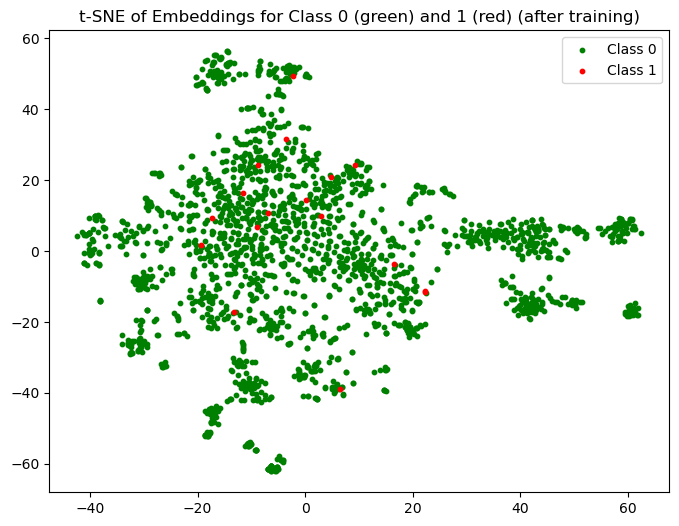

In [96]:
visualize_tsne_binary(gae_model, train_batch, stage='after')

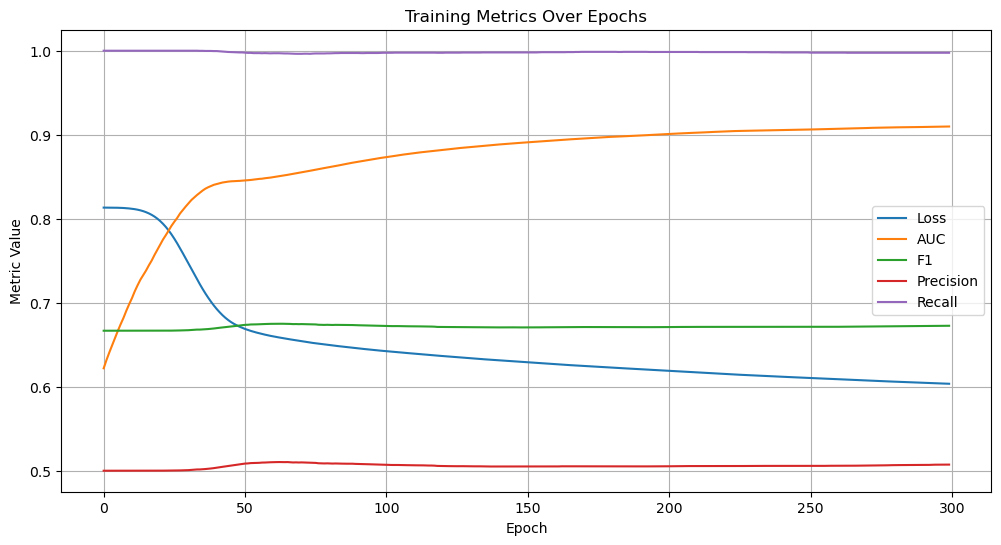

In [141]:
plt.figure(figsize=(12, 6))
plt.plot(loss_list, label='Loss')
plt.plot(auc_list, label='AUC')
plt.plot(f1_list, label='F1')
plt.plot(precision_list, label='Precision')
plt.plot(recall_list, label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Training Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

Min score: 0.5000, Max score: 0.7311
Fraction > 0.5: 0.9832


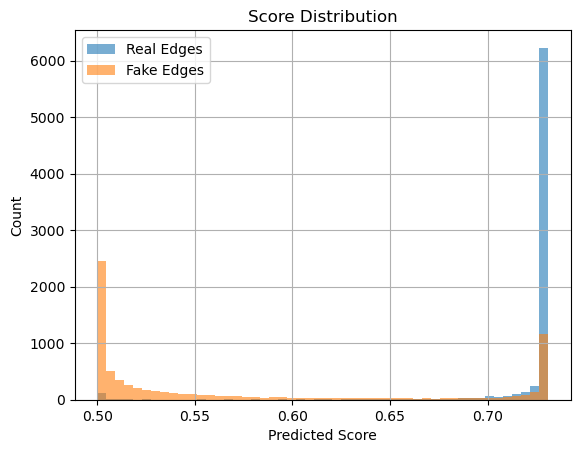

In [142]:
with torch.no_grad():
    _ = gae_model.eval()
    z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
    logits = gae_model.decode(z, train_batch.edge_label_index.squeeze(0)).view(-1)
    probs = torch.sigmoid(logits).cpu()
    
    print(f"Min score: {probs.min().item():.4f}, Max score: {probs.max().item():.4f}")
    print(f"Fraction > 0.5: {(probs > 0.5).float().mean().item():.4f}")
    labels = train_batch.edge_label.squeeze(0).cpu()

    real_scores = probs[labels == 1]
    fake_scores = probs[labels == 0]

    plt.hist(real_scores.numpy(), bins=50, alpha=0.6, label='Real Edges')
    plt.hist(fake_scores.numpy(), bins=50, alpha=0.6, label='Fake Edges')
    plt.xlabel("Predicted Score")
    plt.ylabel("Count")
    plt.title("Score Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

## Train on all sub-graph (1 ~ 41 only)

300 epochs for each sub-graph 

In [84]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Define Encoder
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# Model & Optimizer
in_feats = data.num_node_features
hidden_dim = 128
out_dim = 64
encoder = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.0001)
bce_loss = torch.nn.BCEWithLogitsLoss()

def train_single_graph(train_batch):

    loss_list, auc_list, f1_list, precision_list, recall_list = [], [], [], [], []
    epochs = 300

    for epoch in range(1, epochs + 1):
        _ = gae_model.train()
        optimizer.zero_grad()

        # Forward
        z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
        edge_label_index = train_batch.edge_label_index.squeeze(0)
        edge_label = train_batch.edge_label.squeeze(0).float()
        logits = gae_model.decode(z, edge_label_index).view(-1)

        # Loss
        loss = bce_loss(logits, edge_label)
        loss.backward()
        optimizer.step()

        # Evaluation
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > 0.5).float()
            labels = edge_label.cpu()

            auc = roc_auc_score(labels, probs)
            f1 = f1_score(labels, preds)
            precision = precision_score(labels, preds)
            recall = recall_score(labels, preds)

            # Save metrics
            loss_list.append(loss.item())
            auc_list.append(auc)
            f1_list.append(f1)
            precision_list.append(precision)
            recall_list.append(recall)

            # print(f"probs: {probs}")
            # print(f"edge_label_index: {edge_label_index}")
            # print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    
    return loss_list, auc_list, f1_list, precision_list, recall_list

# print(train_batch)
for t, train_batch in enumerate(dataset):
    if t > 40: break
    print(f"t={t}, train_batch={train_batch}")
    loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)

t=0, train_batch=Data(x=[7880, 165], edge_index=[2, 7361], y=[7880], num_nodes=7880, node_time=[7880], edge_label=[14722], edge_label_index=[2, 14722])
t=1, train_batch=Data(x=[4544, 165], edge_index=[2, 3002], y=[4544], num_nodes=4544, node_time=[4544], edge_label=[6004], edge_label_index=[2, 6004])
t=2, train_batch=Data(x=[6621, 165], edge_index=[2, 4827], y=[6621], num_nodes=6621, node_time=[6621], edge_label=[9654], edge_label_index=[2, 9654])
t=3, train_batch=Data(x=[5693, 165], edge_index=[2, 3957], y=[5693], num_nodes=5693, node_time=[5693], edge_label=[7914], edge_label_index=[2, 7914])
t=4, train_batch=Data(x=[6803, 165], edge_index=[2, 4980], y=[6803], num_nodes=6803, node_time=[6803], edge_label=[9960], edge_label_index=[2, 9960])
t=5, train_batch=Data(x=[4328, 165], edge_index=[2, 2967], y=[4328], num_nodes=4328, node_time=[4328], edge_label=[5934], edge_label_index=[2, 5934])
t=6, train_batch=Data(x=[6048, 165], edge_index=[2, 5327], y=[6048], num_nodes=6048, node_time=[60

In [85]:
train_mask = (data.y != 2) & data.train_mask
test_mask  = (data.y != 2) & data.test_mask

y_train = data.y[train_mask].cpu().numpy()
y_test  = data.y[test_mask].cpu().numpy()

### RF classifier with only GNE (GAE Node Embedding)

In [86]:
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score

# get node embeddings
gae_model.eval()  # Important: turn off dropout etc. during inference
with torch.no_grad():
    z = gae_model.encode(data.x, data.edge_index)  # z is of shape [num_nodes, out_dim]


X_train = z[train_mask].cpu().numpy()
X_test  = z[test_mask].cpu().numpy()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

prec,rec,f1,num = precision_recall_fscore_support(y_test, y_pred)

print("Random Forest with only AF:")
print("Precision: %.3f \nRecall: %.3f \nF1 Score: %.3f"%(prec[1],rec[1],f1[1]))
micro_f1 = f1_score(y_test, y_pred, average='micro')
print("Micro-Average F1 Score: %.3f"%(micro_f1))


# acc  = accuracy_score(y_test, y_pred)
# prec = precision_score(y_test, y_pred, average='macro')
# rec  = recall_score(y_test, y_pred, average='macro')
# f1   = f1_score(y_test, y_pred, average='macro')

# print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Random Forest with only AF:
Precision: 0.766 
Recall: 0.133 
F1 Score: 0.227
Micro-Average F1 Score: 0.941


### RF classifier with GNE + AF

In [88]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score

z_augmented = torch.cat([data.x, z], dim=1)  # shape: [202804, 310]

X_train_aug = z_augmented[train_mask].cpu().numpy()
X_test_aug  = z_augmented[test_mask].cpu().numpy()

rf_aug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aug.fit(X_train_aug, y_train)

y_pred_aug = rf_aug.predict(X_test_aug)

prec,rec,f1,num = precision_recall_fscore_support(y_test, y_pred_aug)

print("Random Forest with only AF:")
print("Precision: %.3f \nRecall: %.3f \nF1 Score: %.3f"%(prec[1],rec[1],f1[1]))
micro_f1 = f1_score(y_test, y_pred_aug, average='micro')
print("Micro-Average F1 Score: %.3f"%(micro_f1))


# acc  = accuracy_score(y_test, y_pred_aug)
# prec = precision_score(y_test, y_pred_aug, average='macro')
# rec  = recall_score(y_test, y_pred_aug, average='macro')
# f1   = f1_score(y_test, y_pred_aug, average='macro')

# print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Random Forest with only AF:
Precision: 0.965 
Recall: 0.717 
F1 Score: 0.823
Micro-Average F1 Score: 0.980


### RF Classifier with only AF

In [75]:
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score

X_train_af = data.x[train_mask].cpu().numpy()
X_test_af  = data.x[test_mask].cpu().numpy()

rf_af = RandomForestClassifier(n_estimators=100, random_state=42)
rf_af.fit(X_train_af, y_train)

y_pred_af = rf_af.predict(X_test_af)

prec,rec,f1,num = precision_recall_fscore_support(y_test, y_pred_af)

print("Random Forest with only AF:")
print("Precision: %.3f \nRecall: %.3f \nF1 Score: %.3f"%(prec[1],rec[1],f1[1]))
micro_f1 = f1_score(y_test, y_pred_af, average='micro')
print("Micro-Average F1 Score: %.3f"%(micro_f1))

# acc  = accuracy_score(y_test, y_pred_af)
# prec = precision_score(y_test, y_pred_af, average=None)
# rec  = recall_score(y_test, y_pred_af, average=None)
# f1   = f1_score(y_test, y_pred_af, average='macro')

# print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec[1]:.4f}, Rec: {rec[1]:.4f}, F1: {f1:.4f}")

Random Forest with only AF:
Precision: 0.960 
Recall: 0.723 
F1 Score: 0.825
Micro-Average F1 Score: 0.980


## Joint learning

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, GAE

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)  # latent embedding z
    

class GATEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=1, dropout=0.6):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)  # latent embedding z


class EllipticTHeGAE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_classes, use_projection=True):
        super().__init__()
        # self.encoder = GCNEncoder(in_channels, hidden_channels, out_channels)
        self.encoder = GATEncoder(in_channels, hidden_channels, out_channels, heads=8, dropout=0.6)
        self.gae = GAE(self.encoder)

        # Node classifier on z (HGNN classifier)
        self.node_classifier = torch.nn.Sequential(
            torch.nn.Linear(out_channels, out_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(out_channels, num_classes)
        )

        # Optional projection for FBC
        self.use_projection = use_projection
        if use_projection:
            self.project = torch.nn.Linear(in_channels, out_channels)

        # Feature-based classifier
        self.fbc = torch.nn.Sequential(
            torch.nn.ReLU(),
            torch.nn.Linear(out_channels if use_projection else in_channels, num_classes)
        )

    def forward(self, x, edge_index):
        z = self.gae.encode(x, edge_index)              # latent node embedding
        out_main = self.node_classifier(z)              # HGNN classifier head

        if self.use_projection:
            x_proj = self.project(x)
            out_fbc = self.fbc(x_proj)
        else:
            out_fbc = self.fbc(x)

        return z, out_main, out_fbc

    def recon_loss(self, z, pos_edge_index, neg_edge_index=None):
        return self.gae.recon_loss(z, pos_edge_index, neg_edge_index)

    def decode(self, z, edge_index):
        return self.gae.decoder(z, edge_index)


class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_term = self.alpha * (1 - pt) ** self.gamma
        loss = focal_term * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


def ae_weight_raw(t, e, T=49, E=300, max_w=0.7, min_w=0.05):
    """AE: decreases with time and epoch"""
    time_factor = 1.0 - (t - 1) / (T - 1)
    epoch_factor = 1.0 - e / (E - 1)
    return max_w * time_factor * epoch_factor + min_w

def fbc_weight_raw(e, E=300, max_w=0.2, min_w=0.05):
    """FBC: increases with epoch"""
    return min_w + (max_w - min_w) * (e / (E - 1))


In [ ]:
model = EllipticTHeGAE(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=64,
    num_classes=2,  # or 3 for unknowns
    use_projection=True
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
ce_loss = torch.nn.CrossEntropyLoss()
# focal_loss = FocalLoss(alpha=0.25, gamma=2.0, reduction='mean')
bce_loss = torch.nn.BCEWithLogitsLoss()


def joint_training_subgraph(sub_graph_t, model, epochs=300):

    if sub_graph_t is None or sub_graph_t.edge_index.size(1) == 0:  # no edges in the subgraph
        return
    
    unknown_mask = sub_graph_t.y != 2  # mask for unknown nodes

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        z, out_main, out_fbc = model(sub_graph_t.x.squeeze(0), sub_graph_t.edge_index.squeeze(0))

        edge_label_index = sub_graph_t.edge_label_index.squeeze(0)
        edge_label = sub_graph_t.edge_label.squeeze(0).float()
        logits = model.decode(z, edge_label_index).view(-1)

        loss_main = ce_loss(out_main[unknown_mask], sub_graph_t.y[unknown_mask])
        loss_fbc  = ce_loss(out_fbc[unknown_mask], sub_graph_t.y[unknown_mask])
        # loss_ae   = model.recon_loss(z, sub_graph_t.pos_edge_index, sub_graph_t.neg_edge_index)
        # loss_ae   = focal_loss(logits, edge_label)
        loss_ae   = bce_loss(logits, edge_label)
        
        w_ae = ae_weight_raw(t, epoch)
        w_fbc = fbc_weight_raw(epoch)
        w_main = 1.0 - (w_ae + w_fbc)

        # Apply dynamic AE loss weight
        loss = w_main * loss_main + w_fbc * loss_fbc + w_ae * loss_ae
        
        loss.backward()
        optimizer.step()
        optimizer.step()

        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | loss_main: {loss_main.item():.4f} | loss_fbc: {loss_fbc.item():.4f} | loss_ae: {loss_ae.item():.4f}")
        
for t in range(1, 50):  # time steps 1–49
    print(f"Training subgraph {t}")
    sub_graph_t = dataset[t - 1]
    joint_training_subgraph(sub_graph_t, model)
    pass

Training subgraph 1
Epoch 001 | Loss: 0.7746 | loss_main: 0.6668 | loss_fbc: 0.6602 | loss_ae: 0.8115
Epoch 002 | Loss: 0.7472 | loss_main: 0.5584 | loss_fbc: 0.5704 | loss_ae: 0.8108
Epoch 003 | Loss: 0.7242 | loss_main: 0.4698 | loss_fbc: 0.4962 | loss_ae: 0.8104
Epoch 004 | Loss: 0.7045 | loss_main: 0.3948 | loss_fbc: 0.4348 | loss_ae: 0.8101
Epoch 005 | Loss: 0.6875 | loss_main: 0.3310 | loss_fbc: 0.3837 | loss_ae: 0.8101
Epoch 006 | Loss: 0.6728 | loss_main: 0.2763 | loss_fbc: 0.3407 | loss_ae: 0.8104
Epoch 007 | Loss: 0.6599 | loss_main: 0.2296 | loss_fbc: 0.3041 | loss_ae: 0.8106
Epoch 008 | Loss: 0.6486 | loss_main: 0.1901 | loss_fbc: 0.2726 | loss_ae: 0.8110
Epoch 009 | Loss: 0.6387 | loss_main: 0.1571 | loss_fbc: 0.2453 | loss_ae: 0.8113
Epoch 010 | Loss: 0.6302 | loss_main: 0.1300 | loss_fbc: 0.2215 | loss_ae: 0.8115
Epoch 011 | Loss: 0.6229 | loss_main: 0.1083 | loss_fbc: 0.2008 | loss_ae: 0.8117
Epoch 012 | Loss: 0.6166 | loss_main: 0.0915 | loss_fbc: 0.1827 | loss_ae: 0.8

In [156]:
from sklearn.metrics import precision_recall_fscore_support

test_mask  = (data.y != 2) & data.test_mask
y_test  = data.y[test_mask].cpu().numpy()

model.eval()
with torch.no_grad():
    z, out_main, out_fbc = model(data.x, data.edge_index)

y_pred = torch.argmax(out_main[test_mask], dim=1).cpu().numpy()


prec,rec,f1,num = precision_recall_fscore_support(y_test, y_pred)
print("Random Forest with only AF:")
print("Precision: %.3f \nRecall: %.3f \nF1 Score: %.3f"%(prec[1],rec[1],f1[1]))

micro_f1 = f1_score(y_test, y_pred, average='micro')
print("Micro-Average F1 Score: %.3f"%(micro_f1))

Random Forest with only AF:
Precision: 0.300 
Recall: 0.339 
F1 Score: 0.318
Micro-Average F1 Score: 0.906


In [ ]:
data.x.shape

tensor([[-0.1696, -0.1847, -1.2014,  ..., -0.1406,  1.5197,  1.5214],
        [-0.1376, -0.1847, -1.2014,  ..., -0.0975, -0.1206, -0.1198],
        [-0.1701, -0.1847, -1.2014,  ..., -0.0975, -0.1206, -0.1198],
        ...,
        [-0.1670, -0.1396,  1.0186,  ..., -0.0545, -1.7609, -1.7610],
        [-0.1722, -0.1396,  1.0186,  ...,  0.4194,  1.5197,  1.5214],
        [-0.1722, -0.1396,  1.0186,  ..., -0.1406, -1.7609, -1.7610]])

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Define Encoder
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# Model & Optimizer
in_feats = data.num_node_features
hidden_dim = 128
out_dim = 64
encoder = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.0001)
bce_loss = torch.nn.BCEWithLogitsLoss()

def train_single_graph(train_batch):

    loss_list, auc_list, f1_list, precision_list, recall_list = [], [], [], [], []
    epochs = 300

    for epoch in range(1, epochs + 1):
        _ = gae_model.train()
        optimizer.zero_grad()

        # Forward
        z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
        edge_label_index = train_batch.edge_label_index.squeeze(0)
        edge_label = train_batch.edge_label.squeeze(0).float()
        logits = gae_model.decode(z, edge_label_index).view(-1)

        # Loss
        loss = bce_loss(logits, edge_label)
        loss.backward()
        optimizer.step()

        # Evaluation
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > 0.5).float()
            labels = edge_label.cpu()

            auc = roc_auc_score(labels, probs)
            f1 = f1_score(labels, preds)
            precision = precision_score(labels, preds)
            recall = recall_score(labels, preds)

            # Save metrics
            loss_list.append(loss.item())
            auc_list.append(auc)
            f1_list.append(f1)
            precision_list.append(precision)
            recall_list.append(recall)

            # print(f"probs: {probs}")
            # print(f"edge_label_index: {edge_label_index}")
            # print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    
    return loss_list, auc_list, f1_list, precision_list, recall_list

# print(train_batch)
for t, train_batch in enumerate(dataset):
    if t > 40: break
    print(f"t={t}, train_batch={train_batch}")
    loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)

## GAE, GCN

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import f1_score, precision_score, recall_score

class NodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.lin = torch.nn.Linear(in_channels, num_classes)
    def forward(self, z):
        return self.lin(z)

in_feats    = data.num_node_features
hidden_dim  = 256
out_dim     = 128
num_classes = int(data.y[data.y != 2].max() + 1)

classifier = NodeClassifier(out_dim, num_classes)

optimizer = torch.optim.Adam(
    list(classifier.parameters()),
    lr=0.001
)
ce_loss  = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

# get node embeddings
gae_model.eval()  # Important: turn off dropout etc. during inference
with torch.no_grad():
    z = gae_model.encode(data.x, data.edge_index)  # z is of shape [num_nodes, out_dim]

# training loop
for epoch in range(300):
    classifier.train()
    optimizer.zero_grad()
    out = classifier(z)  # shape [num_nodes, num_classes]
    train_mask = (data.y != 2) & data.train_mask
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

classifier.eval()
with torch.no_grad():
    out = classifier(z)
    pred = out.argmax(dim=1)
    test_mask = (data.y != 2) & data.test_mask
    acc = (pred[test_mask] == data.y[test_mask]).float().mean()
    prec = precision_score(data.y[test_mask], pred[test_mask], average='macro')
    rec  = recall_score(data.y[test_mask], pred[test_mask], average='macro')
    f1   = f1_score(data.y[test_mask], pred[test_mask], average='macro')
    print(f"Test Acc={acc:.4f} | "
            f"Precision={prec:.4f} | "
            f"Recall={rec:.4f} | "
            f"F1={f1:.4f}")



Epoch 0, Loss: 0.8139
Epoch 1, Loss: 0.4654
Epoch 2, Loss: 0.3829
Epoch 3, Loss: 0.3674
Epoch 4, Loss: 0.3713
Epoch 5, Loss: 0.3794
Epoch 6, Loss: 0.3857
Epoch 7, Loss: 0.3882
Epoch 8, Loss: 0.3870
Epoch 9, Loss: 0.3830
Epoch 10, Loss: 0.3772
Epoch 11, Loss: 0.3710
Epoch 12, Loss: 0.3657
Epoch 13, Loss: 0.3621
Epoch 14, Loss: 0.3605
Epoch 15, Loss: 0.3602
Epoch 16, Loss: 0.3599
Epoch 17, Loss: 0.3584
Epoch 18, Loss: 0.3551
Epoch 19, Loss: 0.3501
Epoch 20, Loss: 0.3442
Epoch 21, Loss: 0.3382
Epoch 22, Loss: 0.3330
Epoch 23, Loss: 0.3288
Epoch 24, Loss: 0.3254
Epoch 25, Loss: 0.3226
Epoch 26, Loss: 0.3200
Epoch 27, Loss: 0.3172
Epoch 28, Loss: 0.3141
Epoch 29, Loss: 0.3110
Epoch 30, Loss: 0.3079
Epoch 31, Loss: 0.3051
Epoch 32, Loss: 0.3027
Epoch 33, Loss: 0.3008
Epoch 34, Loss: 0.2991
Epoch 35, Loss: 0.2974
Epoch 36, Loss: 0.2958
Epoch 37, Loss: 0.2940
Epoch 38, Loss: 0.2922
Epoch 39, Loss: 0.2907
Epoch 40, Loss: 0.2895
Epoch 41, Loss: 0.2887
Epoch 42, Loss: 0.2881
Epoch 43, Loss: 0.287